### **1. Nhập thư viện và dữ liệu**

In [25]:
#Thư viện xử lý dữ liệu
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

#Thư viện preprocessing và modeling
from imblearn.under_sampling import RandomUnderSampler  
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn import metrics 
from imblearn.pipeline import Pipeline
import joblib 


In [2]:
path = Path('data') / 'AIML Dataset.csv'
data = pd.read_csv(path)

### **2. Feature Engineering và Preprocessing**

Loại bỏ các biến không dùng đến trong mô hình:

Dựa vào kết quả của EDA, ta sẽ tạo biến hour thể hiện khung giờ giao dịch: 

In [3]:
data['hour'] = data['step'] % 24

In [4]:
data = data.drop(columns = ['step', 'nameOrig', 'nameDest', 'isFlaggedFraud'] )

Encode các biến chữ:

In [5]:
le = LabelEncoder()
data['type'] = le.fit_transform(data['type'])
data.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour
0,3,9839.64,170136.0,160296.36,0.0,0.0,0,1
1,3,1864.28,21249.0,19384.72,0.0,0.0,0,1
2,4,181.00,181.0,0.00,0.0,0.0,1,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,1
4,3,11668.14,41554.0,29885.86,0.0,0.0,0,1


Chia tệp train - test: 

In [6]:
x = data.drop(columns = ['isFraud'])
y = data['isFraud']
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.3, stratify = y, random_state =0)


Từ kết luận của EDA, ta thấy biến isFraud có vấn đề class imbalance nghiêm trọng. Một số giải pháp có thể sử dụng: 
- **Resample**: downsample xuống tỉ lệ 20:1, 15:1 hoặc 10:1 do bộ dữ liệu có 6 triệu quan sát, trong khi chỉ có vài nghìn Fraud
- **SMOTE**: tạo thêm quan sát cho class Fraud 

-> Vì bộ dữ liệu có 6 triệu quan sát nên **tôi chọn downsample để đẩy nhanh tốc độ train model**, tuy nhiên trong thực tiễn, SMOTE sẽ mang lại kết quả tốt hơn. **Điều này sẽ được thực hiện trong pipeline train model.**

### **3. Train model**

**Random Forest** và **XGBoost** sẽ được train để phân biệt Fraud và Non-Fraud. Các mô hình tuyến tính như Logistic regression sẽ không được sử dụng theo như kết quả từ EDA.  

In [14]:
models = {
    'XGBoost': {
        'model' : XGBClassifier(objective = 'binary:logistic', random_state = 0),
        'para' : {'model__max_depth' : [2,4,6], 'model__min_child_weight': [1, 3, 5], 'model__n_estimators' : [50, 75, 100], 'model__learning_rate' : [0.05, 0.1, 0.2]}
    }, 
    'Random Forest' : {
        'model' : RandomForestClassifier(random_state = 0),
        'para' : {'model__max_depth' : [2,4,6], 'model__min_samples_leaf': [1, 5], 'model__n_estimators' : [50, 75], 'model__min_samples_split' : [2,10], 'model__max_features': ['sqrt']}
    }
}

Fit tệp train và tạo bảng:

In [17]:
best_model = []
best_estimator = []
# Tạo loop chạy 2 mô hình
for name, config in models.items():
    # Tạo pipeline để downsample tệp train trước khi đưa vào grid và cross validation
    pipe = Pipeline([('down_sample', RandomUnderSampler(sampling_strategy = 0.05)), ('model', config['model'])])
    # Grid Search để tìm mô hình với hyper parameters tối ưu
    grid = GridSearchCV(pipe, config['para'],cv = 5, scoring = 'average_precision', refit = 'average_precision', n_jobs = -1)
    grid.fit(xtrain ,ytrain)
    #Tạo bảng
    pr_auc = grid.best_score_
    best = grid.best_estimator_
    best_estimator.append(best)
    best_model.append({
            'model': name,
            'pr_auc': pr_auc, 
        })
    print(f'Mô hình {name} train thành công!' )
    
table = pd.DataFrame(best_model)

Mô hình XGBoost train thành công!
Mô hình Random Forest train thành công!


Để tránh bias khi chọn mô hình, kết quả metrics so sánh được rút ra từ tệp validate. Do mô hình có class imbalance cao, **metric được chọn là PR AUC (Area Under the Precision-Recall Curve)**, được proxy qua average precision. Kết quả như sau:

In [18]:
table

,model,pr_auc
0,XGBoost,0.942715
1,Random Forest,0.852716


Sau khi cross validate thì mô hình **XGBoost chính xác hơn** trong việc phân loại Fraud, Non-Fraud 

-> Mô hình lựa chọn: **XGBoost**

Lưu mô hình:

In [19]:
joblib.dump(best_estimator[0],'models/xgboost.pickle')

['models/xgboost.pickle']

### **3. Kiểm tra khả năng dự đoán của model trên tệp test**

Load mô hình: 

In [20]:
xgb = joblib.load('models/xgboost.pickle')

Fit tệp test:

In [21]:
ypred = xgb.predict(xtest)

Confusion matrix: 

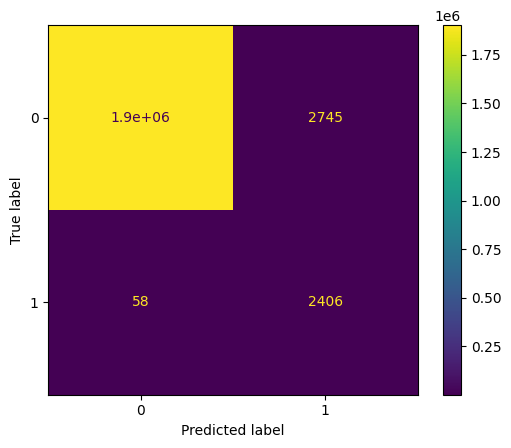

In [22]:
cm = metrics.confusion_matrix(ytest, ypred, labels = xgb.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = xgb.classes_)
disp.plot()

- Có thể thấy: khả năng dự đoán **tương đối cao**, chỉ bị miss 58 giao dịch fraud. 

- Tuy nhiên, mô hình có lượng dương tính giả khá cao (2745 giao dịch)

Classification report:

In [23]:
print(metrics.classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.47      0.98      0.63      2464

    accuracy                           1.00   1908786
   macro avg       0.73      0.99      0.82   1908786
weighted avg       1.00      1.00      1.00   1908786



Do class imbalace cao, nên kết quả sẽ chỉ được đánh giá qua AUC curve.

Text(0.5, 1.0, 'Precision - Recall curve, (ap =0.94)')

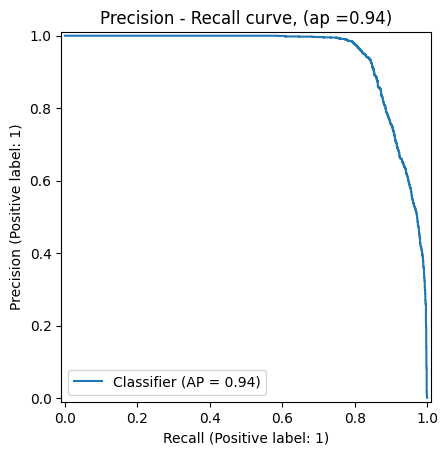

In [27]:
yprob = xgb.predict_proba(xtest)[:,1]
metrics.PrecisionRecallDisplay.from_predictions(ytest, yprob)
ap = metrics.average_precision_score(ytest, yprob)
plt.title(f'Precision - Recall curve, (ap ={round(ap,2)})')


Đường Precision-Recall nằm cao và chỉ giảm mạnh khi recall tiến sát 1.0, cho thấy mô hình hoạt động tốt trong việc ưu tiên đúng các giao dịch Fraud. Average Precision = 0.94 phản ánh **hiệu quả phân biệt Fraud rất tốt trong bối cảnh dữ liệu mất cân bằng**.

=> Kết luận: Trên tệp test:
- Mô hình perform khá tốt, **chỉ miss 63 giao dịch fraud trên tổng ~ 2500 giao dịch fraud**
- Tuy nhiên mô hình **có xu hướng classify khá nhiều giao dịch NonFraud** (**điều này có thể đến từ việc downsample** được thực hiện trong quá trình preprocess khiến cho mô hình học trên **dữ liệu không đúng tỉ lệ so với tệp test**. Tuy nhiên, do bộ dữ liệu có 6 triệu quan sát và để đẩy nhanh tốc độ train mô hình, tôi chấp nhận đánh đổi.)